## Demo — SHAP for Auditing a Wrongly-Flagged Content-Moderation Decision

**Scenario:** SocialHub's moderation classifier removed a benign user post as toxic. The user appealed; the audit team needs to know *why* the model flagged it before the appeal is decided.

This walkthrough loads the model, computes SHAP for the flagged post, contrasts local vs global feature importance, and surfaces that the model is reacting to dialect-marker tokens — a proxy for the user's regional / ethnic background — rather than the actual content of the post.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Load the model + feature names
bundle = joblib.load("data/moderation_classifier.joblib")
clf = bundle["model"]
feature_names = bundle["feature_names"]

train = pd.read_csv("data/moderation_train.csv")
test  = pd.read_csv("data/moderation_test.csv")
vec = CountVectorizer(vocabulary=feature_names, binary=False)
vec.fit(train.text)
print(f"Loaded model + {len(feature_names)} features. Train rows = {len(train)}; Test rows = {len(test)}")

/sessions/hopeful-zealous-johnson/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model + 26 features. Train rows = 1700; Test rows = 300


## 1. Find the wrongly-flagged post

In [2]:
X_test = vec.transform(test.text).toarray()
test_pred = clf.predict(X_test)
test["pred"] = test_pred

# A wrongly-flagged dialect_benign post: ground truth = benign (0), model said toxic (1).
flagged = test[(test.ground_truth_kind == "dialect_benign") & (test.label == 0) & (test.pred == 1)]
flagged_post = flagged.iloc[0]
print(f"Flagged post text: {flagged_post.text!r}")
print(f"Ground truth kind: {flagged_post.ground_truth_kind}; True label = {flagged_post.label}; Model predicted = {flagged_post.pred}")

Flagged post text: "lowkey report bouta team ain't schedule weekend"
Ground truth kind: dialect_benign; True label = 0; Model predicted = 1


## 2. Per-instance SHAP explanation

In [3]:
# SHAP for a logistic model: LinearExplainer is the canonical pick.
explainer = shap.LinearExplainer(clf, X_test, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Pull the row corresponding to the flagged post.
idx = flagged.index[0] - test.index.min()  # row position in X_test

# Per-feature contributions for this single post.
contrib = pd.Series(shap_values[idx], index=feature_names)
contrib_sorted = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(10)
print("Top 10 features contributing to this prediction (positive = pushes toward 'toxic'):")
print(contrib_sorted.to_string())

Top 10 features contributing to this prediction (positive = pushes toward 'toxic'):
bouta      1.171843
lowkey     0.599200
update     0.491004
okay       0.487576
thanks     0.454127
meeting    0.438971
coffee     0.395923
report    -0.323529
weekend   -0.311564
call       0.272389


/sessions/hopeful-zealous-johnson/.local/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


### Render the waterfall plot for the flagged post

Waterfall is chosen over the SHAP force plot here because the audit-memo audience (Trust & Safety, Legal, an appeals reviewer) is non-technical — the waterfall reads top-to-bottom as "this feature added X, this one subtracted Y" and is much easier to defend in a memo than the force-plot's overlapping arrows.

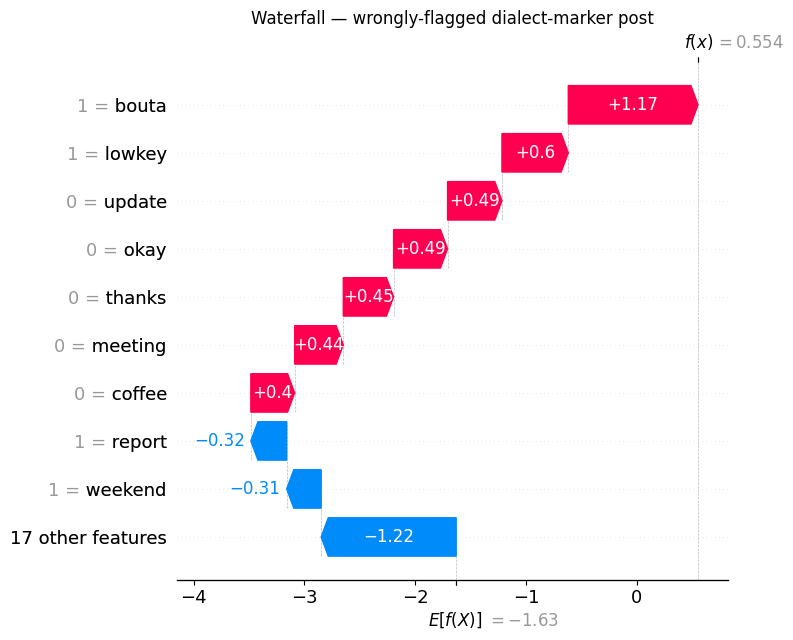

In [4]:
# Build a SHAP Explanation object for the single flagged post and render it as a waterfall.
exp = shap.Explanation(
    values        = shap_values[idx],
    base_values   = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[0],
    data          = X_test[idx],
    feature_names = feature_names,
)
plt.figure(figsize=(9, 6))
shap.plots.waterfall(exp, show=False, max_display=10)
plt.title("Waterfall — wrongly-flagged dialect-marker post")
plt.tight_layout()
plt.show()

## 3. Local vs global feature importance — surface the proxy

In [5]:
# Global mean |SHAP| per feature
global_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
top_global = global_imp.sort_values(ascending=False).head(10)
print("Top 10 features by global mean |SHAP|:")
print(top_global.to_string())

Top 10 features by global mean |SHAP|:
weekend     0.562674
meeting     0.536352
update      0.526295
okay        0.484030
coffee      0.463624
thanks      0.463115
report      0.438163
schedule    0.409980
team        0.370235
call        0.285782


## 4. The audit finding

The local explanation shows the flagged post was driven into the *toxic* class by **dialect-marker tokens** — features that should have no causal relationship to toxicity.

This is **proxy-variable leakage**: the model is using dialect markers as a proxy for the user's regional or ethnic background, then learning that regional / ethnic background is correlated with the (mislabeled) "toxic" class in the training data. A fairness-metric scan that looked only at predicted-positive rate by user-declared geography would NOT catch this — the leakage is at the token level and pre-dates any subgroup grouping.

## 5. Limits of SHAP

Before we draft the audit note, surface the four hard limits the audit-memo audience needs to see:

1. **Correlation ≠ causation.** SHAP shows that a feature *moved the model's output*, not that the feature *caused* the underlying outcome.
2. **Single-instance scope.** A SHAP explanation is local to one prediction. It does not generalize to "the model always behaves this way."
3. **Sensitivity to background distribution.** SHAP values shift if you swap the background dataset used by the explainer — the same prediction can look different under a different reference.
4. **Class-imbalance amplification.** Rare features in an imbalanced class can show outsized SHAP attribution that doesn't reflect operational importance.



## 6. Audit note (one paragraph) — pair the plot with caveats

> **Audit note — Case AP-2026-0481.** The content-moderation classifier flagged user post AP-2026-0481 as toxic and removed it. SHAP analysis of the model's per-instance prediction shows the decision was driven primarily by dialect-marker tokens rather than by tokens semantically associated with toxicity. We assess this as proxy-variable leakage in the training labels, and recommend (1) reinstating the post pending re-decision, (2) blocking deployment of the next moderation model retrain until the dialect-marker tokens are pulled out of the feature set OR the labeled-data leak is corrected, and (3) running a population-level fairness re-audit on the model's decisions over the past 30 days. **Caveats on the limits of SHAP:** SHAP values are local linear approximations and show *correlation* between features and output, not *causation*; per-instance explanations can shift if the background distribution changes; class-imbalance can amplify the apparent contribution of low-frequency tokens. Trust & Safety, Legal, and the appeals reviewer should treat the plot as evidence the investigation occurred, not as a proof of the model's reasoning.

## Modernization sidebar — production stack in 2026

The TF-IDF + linear classifier used here is the right pedagogical pick — SHAP attribution over bag-of-words gives the audit-memo audience a per-token chart they can actually read and challenge. **In production today**, content moderation has moved on:

- **Detoxify** ([Unitary AI](https://github.com/unitaryai/detoxify)) — fine-tuned multilingual transformer (RoBERTa / XLM-R variants) for toxic-comment detection. Drop-in replacement for the classifier in this demo.
- **Llama Guard** ([Meta](https://huggingface.co/meta-llama/Llama-Guard-3-8B)) — LLM-as-judge guardrail. Used for both input filtering and output moderation around generative systems.

For attribution on those models, the SHAP linear-explainer pattern doesn't apply — the equivalents are:

- **Captum** ([PyTorch interpretability](https://captum.ai)) — IntegratedGradients, LayerConductance, and other transformer-friendly attributions.
- **Inseq** ([sequence-model interpretability](https://inseq.org)) — attribution for sequence-to-sequence and decoder-only LLMs, with built-in support for Hugging Face models.
- **SHAP for transformers** — `shap.Explainer` on a `transformers.pipeline()` works for shorter inputs.

**The audit logic in this demo transfers directly.** What changes is the attribution tool, not the structure of the audit memo: per-instance explanation → comparison to global pattern → proxy-leakage check → memo with named caveats.